# Customer Behaviour (Flipkart Reviews): Recommend or Not

Assignment 03, from data representation to deep learning.

This notebook works on a binary classification problem: given the text of a
Flipkart product review and its price, predict whether the reviewer would
recommend the product, defined here as a rating of 4 or 5 stars. We train and
compare four models on the same train/test split: three classical
scikit-learn models, and one deep learning model that we build entirely from
scratch using NumPy, with no TensorFlow, PyTorch, or Keras anywhere in the
implementation.

Every dataset, representation, and model choice below is explained in place,
as a markdown cell right before the code that acts on it, rather than
assumed or left implicit. The numbers that follow are the actual output of
running this notebook end to end, not estimates written ahead of time.


In [1]:
# Core
import numpy as np
import pandas as pd

# Classical ML. scikit-learn is used only for the three classical models;
# the deep learning model further down is implemented from scratch with
# plain NumPy, per the assignment's explicit constraint.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
)
from scipy.sparse import hstack

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Persistence
import joblib
import json
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
# The source file has a corrupted-encoding problem: the original Rupee symbol
# in the Price column was mangled during export into stray bytes, and those
# bytes are not valid UTF-8. Reading with latin-1 lets pandas load every row
# without crashing; the actual numeric cleanup of Price happens later, once
# we can see what we are dealing with.
DATA_PATH = Path("../data/flipkart_reviews.csv")
df_raw = pd.read_csv(DATA_PATH, encoding="latin-1", low_memory=False)
print(f"Loaded {len(df_raw):,} rows, {df_raw.shape[1]} columns")


Loaded 363,261 rows, 5 columns


## Data understanding


In [4]:
print("Shape:", df_raw.shape)
print()
print(df_raw.dtypes)
print()
display(df_raw.head())


Shape: (363261, 5)

Product_name    str
Price           str
Rate            str
Review          str
Summary         str
dtype: object



,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Simply awesome,it's really worth every single penny. it works...
1,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...
2,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the mos...
3,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Fabulous!,Delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Nice product,A Good cooler by Crompton. The height of the c...


In [5]:
display(df_raw.describe(include="all").T)


,count,unique,top,freq
Product_name,363246,1175,Bumtum Baby Pull-Up Diaper Pants Combo Pack - ...,9937
Price,363245,709,"??4,499",12633
Rate,363245,9,5,203832
Review,363239,3841,Wonderful,18567
Summary,361239,165850,Good,25001


In [6]:
missing = df_raw.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df_raw) * 100).round(2)
display(missing)


,n_missing,pct_missing
Product_name,15,0.00
Price,16,0.00
Rate,16,0.00
Review,22,0.01
Summary,2022,0.56


Rows with an unparseable or out-of-range Rate: 44


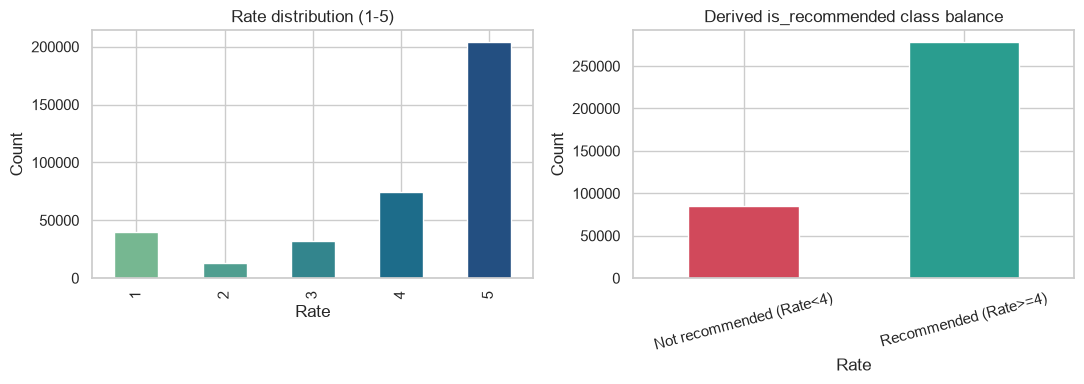

In [7]:
# Rate loads as an object column rather than a clean integer, which is a hint
# that something in the file is not well formed. A handful of rows turn out
# to have a duplicated header embedded partway through the file, plus a few
# rows where the columns are shifted. We coerce Rate to numeric here so we
# can see the real distribution and count how many rows are affected, before
# deciding what to do with them in the cleaning section.
rate_numeric = pd.to_numeric(df_raw["Rate"], errors="coerce")
n_bad_rate = rate_numeric.isna().sum() + (~rate_numeric.between(1, 5)).sum()
print(f"Rows with an unparseable or out-of-range Rate: {int(n_bad_rate):,}")

is_recommended_preview = (rate_numeric >= 4).astype("float")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rate_numeric.dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=sns.color_palette("crest", 5)
)
axes[0].set_title("Rate distribution (1-5)")
axes[0].set_xlabel("Rate")
axes[0].set_ylabel("Count")

is_recommended_preview.dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#d1495b", "#2a9d8f"]
)
axes[1].set_xticklabels(["Not recommended (Rate<4)", "Recommended (Rate>=4)"], rotation=15)
axes[1].set_title("Derived is_recommended class balance")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


Ratings pile up heavily at 5 stars, and the target we derive from them
inherits that same skew: most reviews end up labeled as recommended. This is
a familiar pattern in review data. People who bother to leave a review after
a good experience often just leave a quick five-star rating, while it takes a
genuinely bad experience to motivate a low score. Because of this imbalance,
accuracy on its own would look artificially good for a model that leans
toward predicting the majority class, so we lean on precision, recall, and
F1, already required by the assignment, to judge the models fairly.


C:\Users\minorin\AppData\Local\Temp\ipykernel_16100\4049949841.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Rate", y="review_len", showfliers=False, palette="crest")


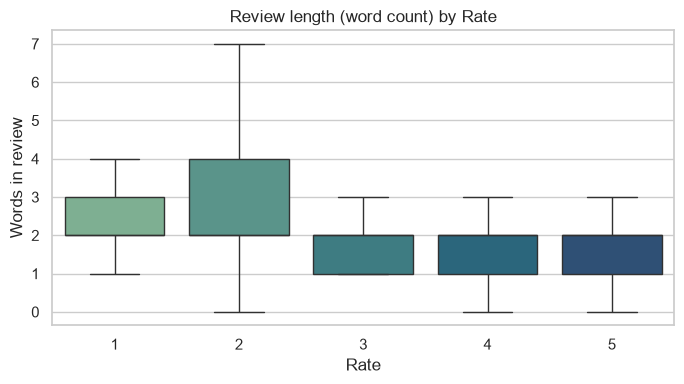

In [8]:
review_len = df_raw["Review"].fillna("").astype(str).str.split().apply(len)
plot_df = pd.DataFrame({"Rate": rate_numeric, "review_len": review_len})
plot_df = plot_df[plot_df["Rate"].between(1, 5)]
plot_df["Rate"] = plot_df["Rate"].astype(int)

plt.figure(figsize=(7, 4))
sns.boxplot(data=plot_df, x="Rate", y="review_len", showfliers=False, palette="crest")
plt.title("Review length (word count) by Rate")
plt.ylabel("Words in review")
plt.tight_layout()
plt.show()


Reviews with a low rating tend to run noticeably longer than five-star
reviews. That fits how people actually write reviews: a happy customer often
just says "nice product" and moves on, while someone who is disappointed
tends to explain exactly what went wrong. This matters for the representation
we build later, because it means review length itself already carries some
sentiment signal, even before the model looks at which words are used.


Rows where Price fails to parse as a plain number before cleaning: 363,261 / 363,261


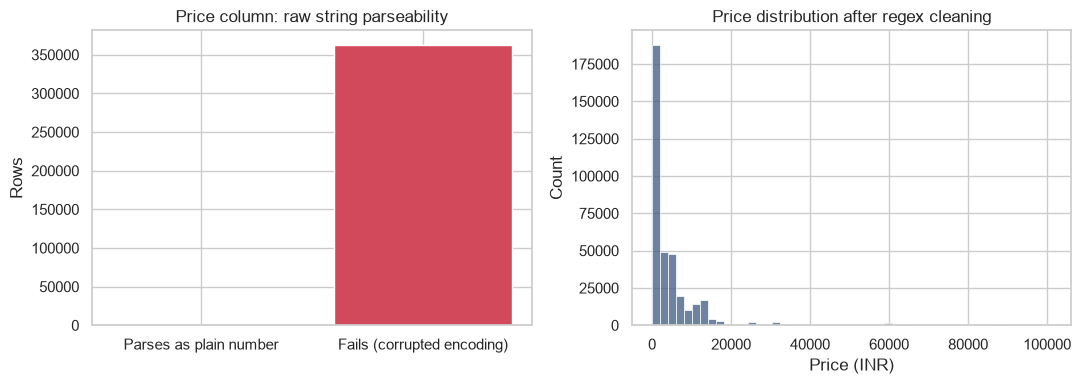

In [9]:
naive_numeric_price = pd.to_numeric(df_raw["Price"], errors="coerce")
n_unparseable = naive_numeric_price.isna().sum()
print(f"Rows where Price fails to parse as a plain number before cleaning: "
      f"{n_unparseable:,} / {len(df_raw):,}")

price_cleaned_preview = pd.to_numeric(
    df_raw["Price"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
    errors="coerce",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(
    ["Parses as plain number", "Fails (corrupted encoding)"],
    [len(df_raw) - n_unparseable, n_unparseable],
    color=["#2a9d8f", "#d1495b"],
)
axes[0].set_title("Price column: raw string parseability")
axes[0].set_ylabel("Rows")

sns.histplot(price_cleaned_preview.dropna(), bins=50, ax=axes[1], color="#3d5a80")
axes[1].set_title("Price distribution after regex cleaning")
axes[1].set_xlabel("Price (INR)")
plt.tight_layout()
plt.show()


Almost every row fails to parse as a plain number before we clean it, which
confirms what the encoding warning earlier suggested: the Rupee symbol did
not survive the export, and what is left behind breaks a simple numeric
conversion. Once we strip everything except digits and the decimal point,
Price turns into a normal-looking retail price distribution: lots of cheaper
items, and a long tail of expensive electronics pulling the mean upward. That
skew is also why we standardize Price with a scaler fit on the training data
rather than treating it as already comparable across rows.


C:\Users\minorin\AppData\Local\Temp\ipykernel_16100\3992369285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_products.index, x=top_products.values, palette="crest", orient="h")
C:\Users\minorin\AppData\Local\Temp\ipykernel_16100\3992369285.py:8: UserWarning: Glyph 152 (\x98) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\minorin\AppData\Local\Temp\ipykernel_16100\3992369285.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
F:\Code\intelligent_system_assignments\assignment_03\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 152 (\x98) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


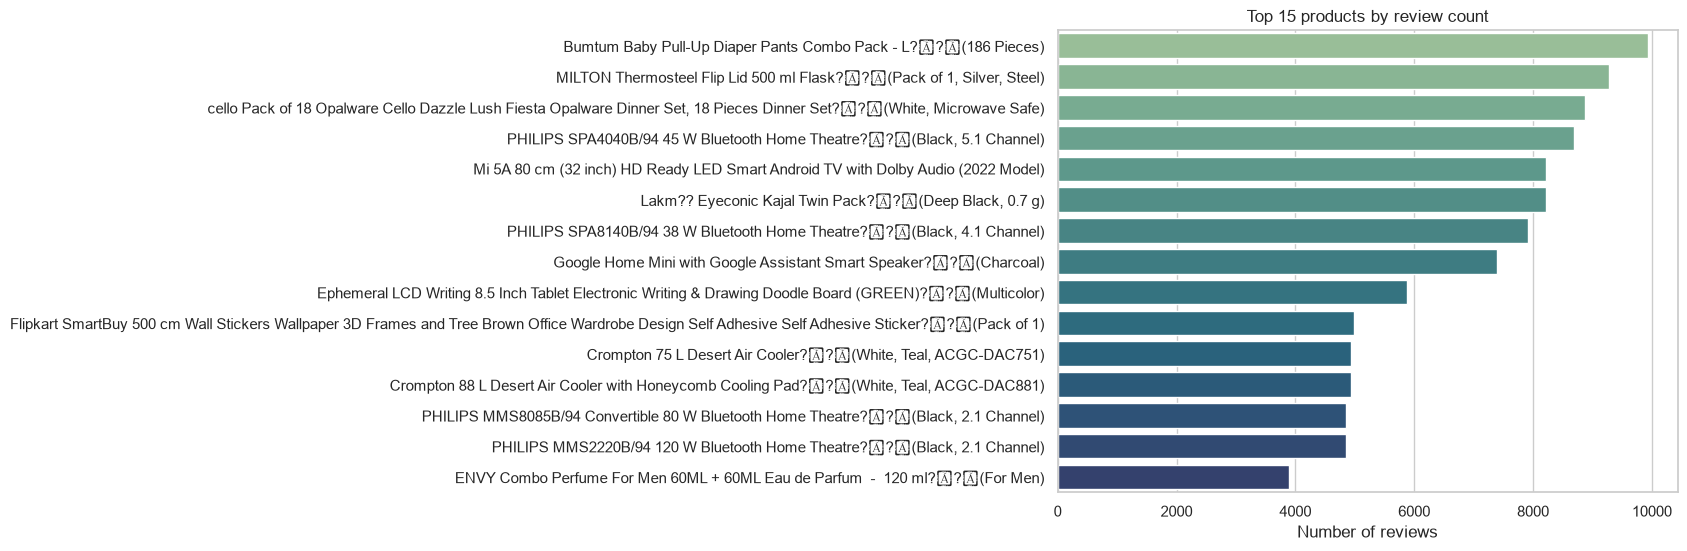

In [10]:
top_products = df_raw["Product_name"].value_counts().head(15)

plt.figure(figsize=(8, 6))
sns.barplot(y=top_products.index, x=top_products.values, palette="crest", orient="h")
plt.title("Top 15 products by review count")
plt.xlabel("Number of reviews")
plt.ylabel("")
plt.tight_layout()
plt.show()


Review volume is concentrated in a small set of popular appliances and
electronics. Most other products in the catalog show up only a handful of
times each. This long tail is exactly why we leave `Product_name` out of the
feature set later: encoding thousands of mostly one-off product titles would
mainly teach a model to memorize training rows rather than to generalize.


Rows: 363,261
Unique Review texts: 3,842 (1.06% of rows)
Rows with a Summary present: 361,239 (99.44%)
Unique Summary texts: 165,850 (45.91% of the rows that have one)

Most repeated Review texts:
Review
Wonderful              18567
Awesome                11501
Great product          11300
Best in the market!    11270
Classy product         11217
Just wow!              11214
Name: count, dtype: int64

Most repeated Summary texts:


Summary
Good            25001
Nice            13100
Good product     8865
Nice product     6275
Super            4983
Very good        3483
Name: count, dtype: int64


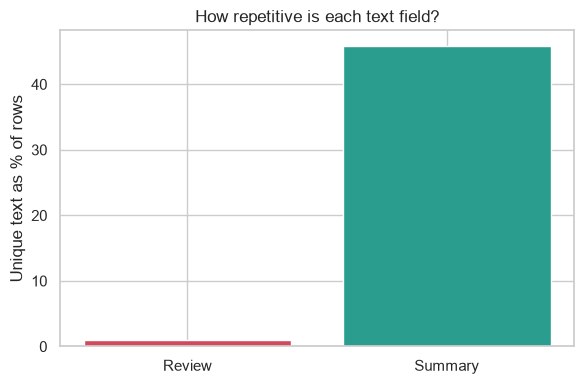

In [11]:
review_filled = df_raw["Review"].fillna("").astype(str)
summary_filled = df_raw["Summary"].fillna("").astype(str)

n_rows = len(df_raw)
n_unique_review = review_filled.nunique()
n_unique_summary = summary_filled[df_raw["Summary"].notna()].nunique()
n_summary_present = df_raw["Summary"].notna().sum()

print(f"Rows: {n_rows:,}")
print(f"Unique Review texts: {n_unique_review:,} ({n_unique_review / n_rows * 100:.2f}% of rows)")
print(f"Rows with a Summary present: {n_summary_present:,} ({n_summary_present / n_rows * 100:.2f}%)")
print(f"Unique Summary texts: {n_unique_summary:,} ({n_unique_summary / n_summary_present * 100:.2f}% of the rows that have one)")
print()
print("Most repeated Review texts:")
print(review_filled.value_counts().head(6))
print()
print("Most repeated Summary texts:")
print(summary_filled[df_raw["Summary"].notna()].value_counts().head(6))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["Review", "Summary"],
    [n_unique_review / n_rows * 100, n_unique_summary / n_summary_present * 100],
    color=["#d1495b", "#2a9d8f"],
)
ax.set_ylabel("Unique text as % of rows")
ax.set_title("How repetitive is each text field?")
plt.tight_layout()
plt.show()


This is the finding that ends up deciding which text field the rest of this
notebook models on. `Review` looks like ordinary free text at a glance, but
it is overwhelmingly a small set of one- or two-word stock phrases repeated
tens of thousands of times each ("Wonderful," "Awesome," "Great product"):
fewer than 2% of rows have a Review text that is not a duplicate of some
other row's. `Summary`, on the other hand, is both almost universally
present (over 99% of rows have one) and far richer: nearly half of all
Summary texts are unique to their row, and the ones that repeat tend to be
short one-word summaries ("Good," "Nice") sitting alongside a much longer
tail of genuinely distinct sentences.

That gap matters beyond just "more variety is nicer." A model trained and
evaluated on a text field this repetitive is not really being tested on
new language during evaluation, because most of what shows up in the test
split is a word-for-word copy of something the model already saw during
training -- the evaluation ends up measuring memorization of a small
boilerplate vocabulary rather than genuine generalization to unseen
reviews. `Summary`'s far larger unique vocabulary does not eliminate that
risk entirely (a handful of one-word summaries are extremely common too),
but it cuts it down substantially, which is why the representation section
below builds the TF-IDF input from `Summary` rather than `Review`.


The code below asks, for every distinct Summary text that appears more
than once, how one-sided its label is. `.assign(is_recommended=...)`
adds a temporary `is_recommended` column onto a copy of the data;
`.groupby(summary_filled[...])` then groups every row by its exact Summary
text (grouping by a Series like this, rather than a column name, is what
lets the grouping key be the cleaned/filled text used everywhere else in
this section) and `["is_recommended"].agg(["mean", "count"])` computes, for
each distinct text, the fraction of its rows that are recommended (`mean`
of a 0/1 column is exactly that fraction) and how many rows share that
text (`count`). A text's `mean` alone does not say how one-sided it is,
since 0.05 and 0.95 are both "one-sided" but in opposite directions, which
is why `np.maximum(grp["mean"], 1 - grp["mean"])` takes whichever of the
two is larger and calls it `purity`: 1.0 means every row with that exact
text shares one label, 0.5 means it is a perfect coin flip. The last step,
`summary_filled[...].map(grp["purity"])`, looks up each individual row's
own Summary text in that `purity` table, turning the per-text statistic
into a per-row one so it can be averaged and plotted directly.


Rows whose exact Summary text is >=95% one-class pure: 74.7%
Rows whose exact Summary text is >=90% one-class pure: 88.4%

Purity (share of the majority class) for the most repeated Summary texts:
              count    purity
Summary                      
Good          25001  0.882045
Nice          13100  0.912824
Good product   8865  0.940327
Nice product   6275  0.947570
Super          4983  0.960867
Very good      3483  0.962389
Very nice      2989  0.959853
Ok             2746  0.624909


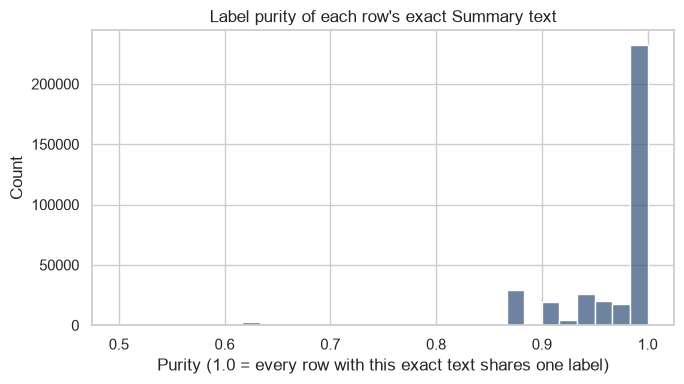

In [12]:
grp = df_raw.loc[df_raw["Summary"].notna()].assign(
    is_recommended=(rate_numeric >= 4).astype(int)
).groupby(summary_filled[df_raw["Summary"].notna()])["is_recommended"].agg(["mean", "count"])
grp["purity"] = np.maximum(grp["mean"], 1 - grp["mean"])

row_purity = summary_filled[df_raw["Summary"].notna()].map(grp["purity"])
print(f"Rows whose exact Summary text is >=95% one-class pure: {(row_purity >= 0.95).mean() * 100:.1f}%")
print(f"Rows whose exact Summary text is >=90% one-class pure: {(row_purity >= 0.90).mean() * 100:.1f}%")
print()
print("Purity (share of the majority class) for the most repeated Summary texts:")
print(grp.sort_values("count", ascending=False).head(8)[["count", "purity"]])

plt.figure(figsize=(7, 4))
sns.histplot(row_purity, bins=30, color="#3d5a80")
plt.title("Label purity of each row's exact Summary text")
plt.xlabel("Purity (1.0 = every row with this exact text shares one label)")
plt.tight_layout()
plt.show()


This is a second, separate reason the models further down score as well as
they do, distinct from the repetition finding just above. For roughly
three out of four rows, the exact Summary text they contain is at least
95% associated with a single label across every other row that shares that
same text: "Excellent" is recommended 98.7% of the time it appears,
"Very good" 96.2%, even a plain "Good" 88.2% of the time despite being the
single most common Summary in the whole dataset. That is not evaluation
leakage the way the Review-text overlap was; it does not depend on the
model having seen that literal string during training. It is a real
property of how people write these summaries: someone who bothers to type
"Excellent" is overwhelmingly likely to have also given 4 or 5 stars, so a
model that correctly learns "positive sentiment word implies positive
rating" from the training data will score well on any row carrying that
word, seen before or not.

The exception is informative too. "Ok" sits at only 62.5% purity, close to
a coin flip, which is exactly what a genuinely ambiguous word should look
like, and it is reassuring that the purity numbers are not uniformly near
1.0 across the board. That contrast is what separates this finding from a
methodology problem: most short summaries are near-deterministic because
sentiment language genuinely correlates that strongly with rating in this
dataset, not because every possible phrase trivially maps to a label
regardless of what it actually says.


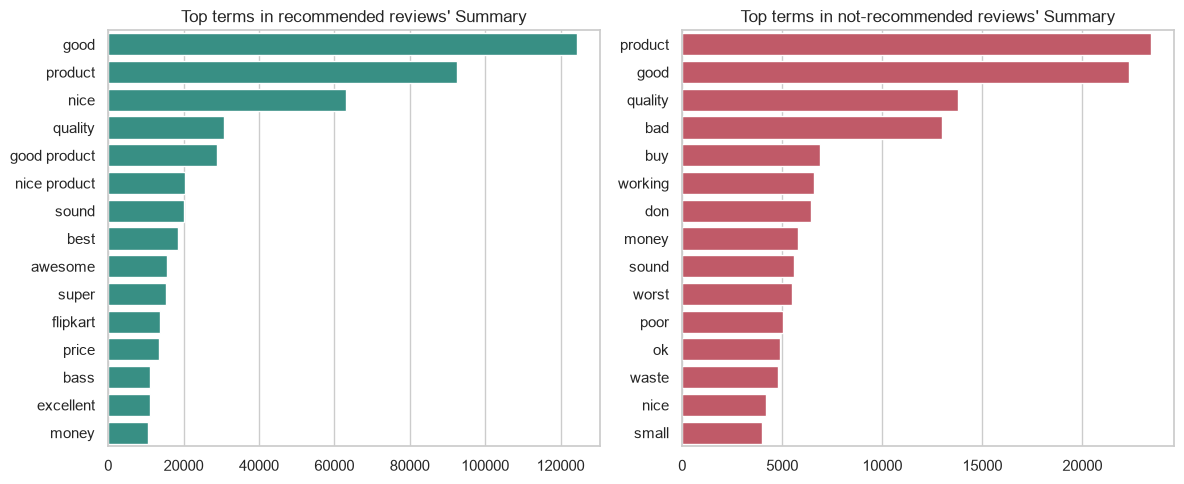

In [13]:
def top_terms(texts, n=15):
    cv = CountVectorizer(stop_words="english", ngram_range=(1, 2), max_features=20000)
    bow = cv.fit_transform(texts)
    counts = np.asarray(bow.sum(axis=0)).ravel()
    vocab = np.array(cv.get_feature_names_out())
    order = np.argsort(counts)[::-1][:n]
    return vocab[order], counts[order]

is_rec_preview = (rate_numeric >= 4) & df_raw["Summary"].notna()
not_rec_preview = (rate_numeric < 4) & df_raw["Summary"].notna()
rec_terms, rec_counts = top_terms(summary_filled[is_rec_preview.fillna(False)])
not_rec_terms, not_rec_counts = top_terms(summary_filled[not_rec_preview.fillna(False)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(y=rec_terms, x=rec_counts, ax=axes[0], color="#2a9d8f", orient="h")
axes[0].set_title("Top terms in recommended reviews' Summary")
sns.barplot(y=not_rec_terms, x=not_rec_counts, ax=axes[1], color="#d1495b", orient="h")
axes[1].set_title("Top terms in not-recommended reviews' Summary")
plt.tight_layout()
plt.show()


The two classes read very differently once we look past the ratings and at
the actual words, even in this richer Summary field. Recommended reviews
lean on short, generic praise like "good product" or "worth every penny,"
while not-recommended reviews surface concrete complaints such as "waste
money," "poor quality," or "not working." That separation is a good sign
for a bag-of-words style representation: the vocabulary itself already
distinguishes the two classes fairly clearly, which means a linear model or
the from-scratch network built further down should have real signal to
work with, not just noise.


## Data cleaning


In [14]:
df = df_raw.copy()
df["Price_clean"] = pd.to_numeric(
    df["Price"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
    errors="coerce",
)


In [15]:
rate_numeric_full = pd.to_numeric(df["Rate"], errors="coerce")
valid_mask = (
    rate_numeric_full.between(1, 5)
    & df["Summary"].notna()
    & df["Price_clean"].notna()
)
n_before = len(df)
df = df[valid_mask].copy()
df["Rate"] = rate_numeric_full[valid_mask].astype(int)
df["is_recommended"] = (df["Rate"] >= 4).astype(int)

print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after dropping unparseable Rate, missing Summary, or missing Price: {len(df):,}")
print(f"Dropped: {n_before - len(df):,} rows "
      f"({(n_before - len(df)) / n_before * 100:.2f}%)")
print()
print(df["is_recommended"].value_counts(normalize=True).rename("share"))


Rows before cleaning: 363,261
Rows after dropping unparseable Rate, missing Summary, or missing Price: 361,233
Dropped: 2,028 rows (0.56%)

is_recommended
1    0.765614
0    0.234386
Name: share, dtype: float64


This step drops rows missing `Summary` rather than `Review`, since the EDA
above just established that `Summary` is the field the representation
section is going to build the TF-IDF input from, not `Review`. Only about
half a percent of rows are missing a Summary, so this costs almost nothing.

A full-row duplicate check also turns up a large number of exact
duplicates: identical product, price, rating, and text. We decided to keep
them rather than drop them. Short generic reviews like "good product" or
"nice" really do get written over and over by different real buyers of the
same popular item at the same price, so collapsing those rows would throw
away genuine signal about how common that kind of review is, not just clean
up parsing artifacts. It is a judgment call worth stating plainly rather
than making silently, and it is exactly why the choice of text field
earlier matters: `Summary`'s much larger unique vocabulary keeps this
duplicate-row decision from turning the evaluation into near-total
memorization the way it would have on `Review`.


## Representation

The `Summary` text becomes a TF-IDF vector over unigrams and bigrams,
rather than `Review`, for the reason established in the EDA section above:
`Review` is overwhelmingly a small set of one- or two-word stock phrases,
while `Summary` is both almost universally present and far richer in
vocabulary, which matters directly for how honestly the train/test split
measures generalization rather than memorization.

We fit two separate vectorizers rather than one, because the two model
families need different vocabulary sizes. The classical models get the full
vocabulary with no artificial cap, which comes out to 416,770 unique terms;
sklearn's sparse linear models handle that size comfortably because the
matrix stays sparse all the way through training. The deep learning model
gets a vocabulary capped at 5,000 terms instead, roughly a two-percent slice
of the full vocabulary, because a dense NumPy forward and backward pass has
no sparse representation to lean on: every one of those columns turns into
a real, materialized number for every row, so 416,770 of them would be far
too slow and memory-hungry to train from scratch. That cap is a deliberate
trade-off made up front to keep the from-scratch model tractable, not
something discovered by accident, and it is also the most direct explanation
for why the from-scratch model trails the classical ones later in this
notebook: it is reading a small fraction of the vocabulary the linear models
get to see.

Price, once cleaned into a number, gets standardized with a scaler fit only
on the training split. Product_name stays out of the feature set for the
reason covered in the EDA above: it is high-cardinality free text that would
mostly encourage memorization. Review itself is dropped entirely rather than
combined with Summary, for the same leakage reason already established: it
is the column where the same handful of stock phrases repeat across train
and test, so adding it back in alongside Summary would just reopen the
memorization shortcut this section is trying to close.


In [16]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["is_recommended"]
)
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")


Train: 288,986 rows | Test: 72,247 rows


In [17]:
price_scaler = StandardScaler()
price_train = price_scaler.fit_transform(train_df[["Price_clean"]])
price_test = price_scaler.transform(test_df[["Price_clean"]])


In [18]:
# Full vocabulary for the classical models. min_df=1 means no term is pruned
# for being rare, and the vectorizer is fit on the training Summary text
# only so nothing from the test set leaks into it.
tfidf_classical = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_df=0.9)
X_train_text_classical = tfidf_classical.fit_transform(train_df["Summary"].astype(str))
X_test_text_classical = tfidf_classical.transform(test_df["Summary"].astype(str))
print(f"Classical TF-IDF vocabulary size: {len(tfidf_classical.vocabulary_):,}")


Classical TF-IDF vocabulary size: 416,770


In [19]:
# Capped vocabulary for the from-scratch DL model, as explained in the
# representation section above. This is a separate vectorizer, again fit on
# the training Summary text only.
tfidf_dl = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_text_dl = tfidf_dl.fit_transform(train_df["Summary"].astype(str))
X_test_text_dl = tfidf_dl.transform(test_df["Summary"].astype(str))
print(f"DL TF-IDF vocabulary size: {len(tfidf_dl.vocabulary_):,}")


DL TF-IDF vocabulary size: 5,000


The TF-IDF matrices built above and the standardized Price column exist
as separate arrays so far, and they need to be joined side by side, one
combined feature matrix per model family, before any model can be fit.

`hstack` (short for "horizontal stack," imported from `scipy.sparse`)
places arrays next to each other column-wise: given a TF-IDF matrix with,
say, 8,000 word columns and a Price column with 1 column, `hstack([...])`
produces a single matrix with 8,001 columns, one row per review, for the
same rows in both inputs. It has to be the sparse-aware version of stacking
rather than plain NumPy's, since the TF-IDF matrices are sparse (mostly
zero) and converting them to dense arrays first, just to stack them, would
waste the memory the sparse format exists to save. `.tocsr()` converts the
result into a specific sparse storage layout (compressed sparse row) that
scikit-learn's classifiers expect for fast row-slicing during training;
`hstack` on its own returns a different sparse layout that is efficient to
build but slow for a model to actually train on.


In [20]:
X_train_classical = hstack([X_train_text_classical, price_train]).tocsr()
X_test_classical = hstack([X_test_text_classical, price_test]).tocsr()

X_train_dl = hstack([X_train_text_dl, price_train]).tocsr().astype(np.float32)
X_test_dl = hstack([X_test_text_dl, price_test]).tocsr().astype(np.float32)

y_train = train_df["is_recommended"].to_numpy()
y_test = test_df["is_recommended"].to_numpy()

print("Classical (TF-IDF full vocab plus Price):", X_train_classical.shape, X_test_classical.shape)
print("DL        (TF-IDF 5000-term cap plus Price):", X_train_dl.shape, X_test_dl.shape)
print("Text-only (for Naive Bayes):", X_train_text_classical.shape, X_test_text_classical.shape)


Classical (TF-IDF full vocab plus Price): (288986, 416771) (72247, 416771)
DL        (TF-IDF 5000-term cap plus Price): (288986, 5001) (72247, 5001)
Text-only (for Naive Bayes): (288986, 416770) (72247, 416770)


## Classical machine learning models

Three models get fit on the same training split before the from-scratch
network gets anywhere near the data, so that the deep learning result later
has something meaningful to be compared against. Each of the three is
included for a different reason, not as three interchangeable variations
on the same idea, and each cell below fits one model and says why that
model specifically belongs in this comparison.


Logistic Regression goes first because it is the simplest model in this
comparison: it works by learning one weight per TF-IDF term (plus one for
Price), combining them linearly, and squashing the result through a
sigmoid, which is architecturally close to a single layer of the network
built from scratch further down, just without the hidden layers. That
makes it a natural reference point for how much the deep network's extra
layers actually buy over a plain linear combination of the same features.
`max_iter=200` gives the solver enough iterations to converge on a feature
space this size without an arbitrary cutoff cutting it off early.


In [21]:
log_reg = LogisticRegression(max_iter=200, solver="lbfgs")
log_reg.fit(X_train_classical, y_train)
print("Logistic Regression fitted.")


Logistic Regression fitted.


A linear support vector machine looks for the hyperplane that separates the
two classes with the widest possible margin, rather than the one that
maximizes likelihood the way Logistic Regression does. That is a genuinely
different objective, and on high-dimensional sparse text features like
TF-IDF vectors it is a classically strong performer, which is why it is the
second model here rather than a second linear model chosen at random.
`dual=False` is set because this problem has more rows than features once
Price is folded in, which is exactly the regime where solving the primal
form is faster than the dual; `max_iter=3000` gives the optimizer enough
room to settle rather than being cut off mid-convergence.


In [22]:
linear_svm = LinearSVC(max_iter=3000, dual=False, random_state=RANDOM_SEED)
linear_svm.fit(X_train_classical, y_train)
print("Linear SVM fitted.")


Linear SVM fitted.


Multinomial Naive Bayes takes a completely different approach from the
first two: instead of learning a decision boundary, it estimates how likely
each word is to appear under each class and combines those probabilities
under the (deliberately simplifying) assumption that words are independent
of each other given the class. That assumption is not really true of
language, but the model trains in a fraction of a second even on hundreds
of thousands of reviews, which makes it a useful lower-bound baseline:
if the other two models cannot clear what this simple model achieves, that
would say more about the representation than about the model. It expects
non-negative input, and the standardized Price column can be negative, so
this model trains on the TF-IDF text block alone. That is a deliberate scope
difference from Logistic Regression and the SVM, not something overlooked.


In [23]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_text_classical, y_train)
print("Multinomial Naive Bayes fitted on text-only input.")


Multinomial Naive Bayes fitted on text-only input.


With all three models fit, the next step is to run each of them on the
held-out test set exactly once. Alongside the hard 0/1 predictions, we also
keep each model's continuous score (a predicted probability for Logistic
Regression and Naive Bayes, a signed distance from the margin for the SVM),
since the ROC curves a few cells down need a continuous score rather than a
hard label to work with.


In [24]:
pred_lr = log_reg.predict(X_test_classical)
pred_svm = linear_svm.predict(X_test_classical)
pred_nb = naive_bayes.predict(X_test_text_classical)

score_lr = log_reg.predict_proba(X_test_classical)[:, 1]
score_svm = linear_svm.decision_function(X_test_classical)
score_nb = naive_bayes.predict_proba(X_test_text_classical)[:, 1]


Accuracy alone would not tell the full story here, given how skewed the
target turned out to be back in the EDA section, so we compute precision,
recall, and F1 alongside it for every model. Precision asks how often a
"recommended" prediction is actually correct, recall asks how many of the
truly recommended reviews the model actually catches, and F1 balances the
two into a single number that is a fairer head-to-head comparison than
accuracy would be on its own.


In [25]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

classical_results = pd.DataFrame({
    "Logistic Regression": classification_metrics(y_test, pred_lr),
    "Linear SVM": classification_metrics(y_test, pred_svm),
    "Multinomial NB": classification_metrics(y_test, pred_nb),
}).T
display(classical_results.style.format("{:.4f}"))


,Accuracy,Precision,Recall,F1
Logistic Regression,0.9250,0.9279,0.9780,0.9523
Linear SVM,0.9295,0.9344,0.9765,0.9550
Multinomial NB,0.9035,0.8951,0.9900,0.9402


The table above gives one number per metric per model, but it collapses
each model's mistakes into a single ratio and hides what kind of mistake
each one is actually making. A confusion matrix keeps that visible: it
splits the test set into the four ways a prediction can land (correctly
recommended, correctly not-recommended, and the two flavors of getting it
wrong) so we can see, model by model, whether errors lean toward false
alarms or missed recommendations.


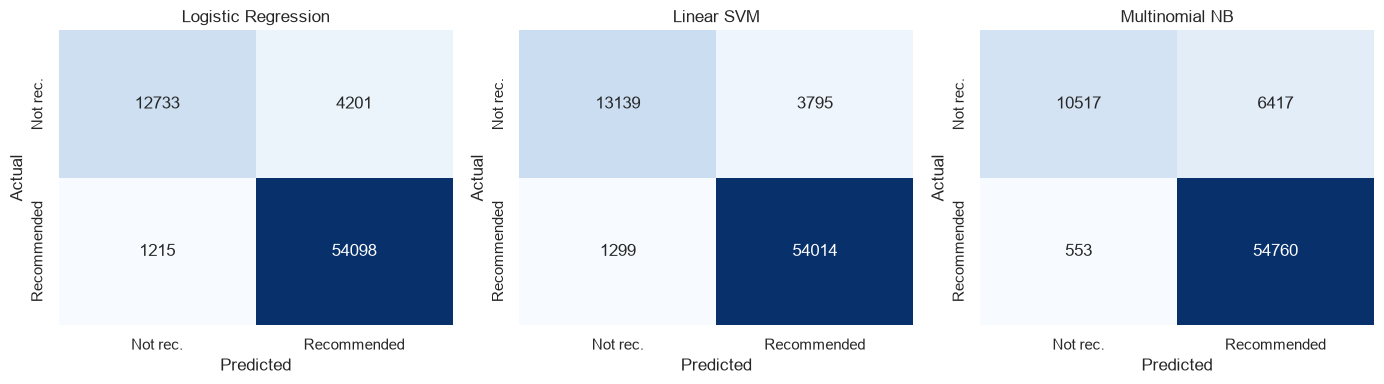

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, pred in zip(
    axes, ["Logistic Regression", "Linear SVM", "Multinomial NB"], [pred_lr, pred_svm, pred_nb]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Not rec.", "Recommended"], yticklabels=["Not rec.", "Recommended"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


The confusion matrices above are all read at one fixed decision threshold,
0.5, but each model actually outputs a continuous score, and moving that
threshold trades recall for precision in a way that a single confusion
matrix cannot show. A ROC curve sweeps through every possible threshold at
once, plotting how the true positive rate and false positive rate move
together as the threshold changes, so it is a fairer way to compare two
models' entire ranking ability rather than just their behavior at one
arbitrarily chosen cutoff. The area under each curve compresses that whole
sweep into a single number for a quick comparison.


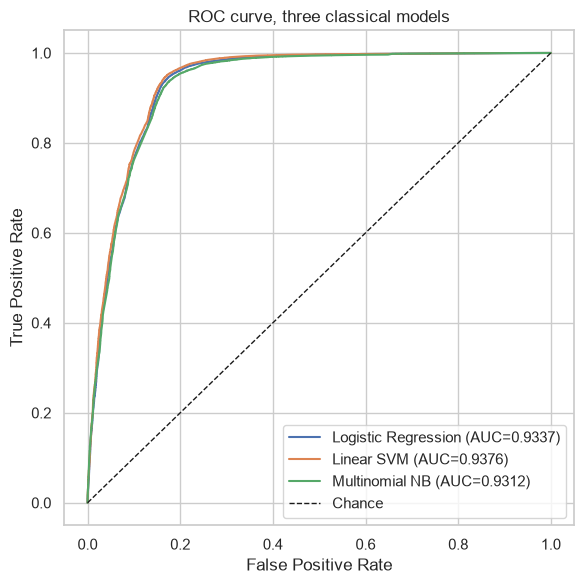

In [27]:
plt.figure(figsize=(6, 6))
for name, score in [("Logistic Regression", score_lr), ("Linear SVM", score_svm), ("Multinomial NB", score_nb)]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve, three classical models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Logistic Regression assigns exactly one coefficient to every input
feature, so its learned weights can be read directly as "how much does
this specific word push the prediction toward recommended or away from
it," a level of transparency neither the SVM's margin nor Naive Bayes's
per-class word probabilities offer quite as directly. The code below
pulls that list of coefficients out and shows the 15 most negative and 15
most positive ones.

`tfidf_classical.get_feature_names_out()` returns the vocabulary the
vectorizer learned, in the same column order the TF-IDF matrix uses, and
`np.append(..., "Price_clean")` tacks the one non-text column onto the end
of that list to match how the feature matrix was assembled earlier.
`log_reg.coef_` comes out of scikit-learn as a 2D array with one row (this
is a binary problem, so there is only one row); `.ravel()` flattens it to
a plain 1D array with one coefficient per feature. Wrapping that in
`pd.Series(coefs, index=all_feature_names)` pairs each coefficient with the
word or column it belongs to, and `.sort_values()` orders that Series from
most negative to most positive, so `.head(15)` and `.tail(15)` grab the
strongest pushes in each direction.


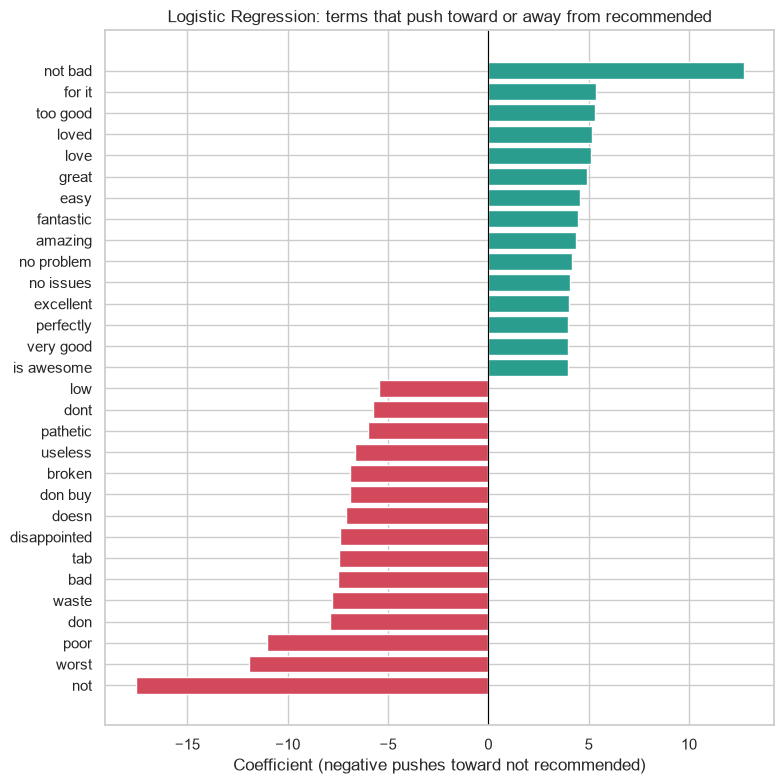

In [28]:
text_feature_names = tfidf_classical.get_feature_names_out()
all_feature_names = np.append(text_feature_names, "Price_clean")
coefs = log_reg.coef_.ravel()

coef_series = pd.Series(coefs, index=all_feature_names).sort_values()
top_negative = coef_series.head(15)
top_positive = coef_series.tail(15)
top_combined = pd.concat([top_negative, top_positive])

plt.figure(figsize=(8, 8))
colors = ["#d1495b" if v < 0 else "#2a9d8f" for v in top_combined.values]
plt.barh(top_combined.index, top_combined.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression: terms that push toward or away from recommended")
plt.xlabel("Coefficient (negative pushes toward not recommended)")
plt.tight_layout()
plt.show()


## Deep learning from scratch, NumPy only

The network has the shape 5000 to 128 to 32 to 1, with ReLU activations on
both hidden layers and a sigmoid output, trained with binary cross-entropy
loss. That first hidden layer is deliberately wide relative to the two
layers after it. TF-IDF input is sparse and high-dimensional, five thousand
columns where most entries are zero for any given row, so the network needs
enough capacity in that first layer to actually compress that information
down into something useful, rather than immediately bottlenecking it.

There is one practical wrinkle worth calling out before the code below. The
input matrix is a scipy sparse matrix, and plain NumPy cannot operate on
sparse matrices directly, so each mini-batch gets converted to a dense array
right before the forward pass. Converting the entire training matrix to
dense in one shot would need several gigabytes of memory just to hold it, so
we train with mini-batch gradient descent specifically to keep that dense
conversion small at each step. This is a decision we are making on purpose,
and it is worth writing down rather than leaving as a quiet implementation
detail.


### ReLU: the hidden-layer activation

ReLU is the activation function for both hidden layers. "Just clips
negative numbers to zero" undersells what that clipping actually buys,
so it is worth walking through the reasoning in order:

1. Without any activation function at all, stacking multiple weight
   layers is mathematically identical to a single layer, since chaining
   matrix multiplications together (`X @ W1 @ W2 @ W3`) collapses into
   one big matrix multiplication. Depth would add nothing, no matter how
   many "layers" get stacked.
2. So every layer needs some nonlinear step in between the
   multiplications. That is what breaks the "collapses into one big
   linear function" problem and lets stacking layers build more complex
   shapes than a single straight line or flat plane could.
3. That naturally raises the question: could this nonlinear step be
   *any* function, picked arbitrarily? Mostly no. It has to be
   deterministic (the same input always produces the same output, or
   the network stops computing a stable function that gradient descent
   could ever converge toward), differentiable almost everywhere (the
   backward pass a few cells down needs to compute a derivative through
   it at every layer, so a function with no usable slope, or a slope of
   0 nearly everywhere, blocks gradient from flowing through), and well
   behaved numerically (not prone to blowing up toward infinity). Within
   those constraints there is a whole family of valid choices, ReLU
   among them.
4. ReLU is one specific member of that family: if the input is positive,
   pass it through unchanged; if it is negative, output exactly zero.
   That is an on/off switch, not just a clip.
5. Each hidden unit becomes a detector that only "fires" for certain
   input patterns. For inputs where its weighted sum comes out negative,
   it stays silent (outputs 0) and contributes nothing to that
   prediction; for inputs where it comes out positive, it passes a
   signal through, scaled by how positive it is.
6. Combine many of these on/off detectors and different units end up
   specializing in different patterns in the data (a unit might fire
   mainly for reviews with strong positive words, say). Stacking these
   selectively firing pieces together is what lets the network
   approximate a complicated decision boundary out of many simple
   pieces, the same way a curve can be approximated out of many short
   straight segments.
7. As a separate, practical bonus, ReLU's derivative is trivial: exactly
   1 where it is "on," exactly 0 where it is "off." That keeps the
   backward pass cheap, and it avoids a real problem older members of
   that same valid family, like sigmoid, have: sigmoid's derivative
   shrinks toward zero the further the input gets from the center, so
   gradients pushed back through many sigmoid layers can shrink toward
   nothing before they even reach the early layers (the "vanishing
   gradient" problem). ReLU mostly sidesteps that, which is the actual
   reason it gets used here rather than being the only option that
   would technically work.

In the code, `np.maximum(0, z)` compares every number in the array `z`
against 0, element by element, and keeps whichever is larger, which is
exactly "zero out anything negative, leave positive numbers alone."
`relu_derivative` needs the slope of that function instead of its value:
`(z > 0)` produces an array of `True`/`False` values, one per element,
`True` wherever the original input was positive, and `.astype(z.dtype)`
converts those into 1.0s and 0.0s of the same numeric type as `z`, which is
exactly the 1-or-0 derivative ReLU has everywhere except at 0.


In [29]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)


### Sigmoid: the output activation

The output layer needs a different function from the hidden layers,
because its job is different: it has to turn one raw number into something
that can be read as a probability of "recommended," meaning it needs to
land strictly between 0 and 1. Sigmoid does exactly that, squashing any
real-valued input into that range while staying smooth and differentiable,
which is what the backward pass below needs.

In the code, `np.exp(-z)` raises `e` (Euler's number, about 2.718) to the
power of `-z` for every element at once, which shrinks toward 0 as `z`
grows large and positive and grows huge as `z` becomes large and negative.
Dividing 1 by `1 + that value` is the sigmoid formula itself, and because
the result always sits somewhere between 0 and 1 regardless of how large
or small `z` gets, the output is guaranteed to be a valid probability.


In [30]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


### Binary cross-entropy: the loss function

Binary cross-entropy is the loss function this network is trained to
minimize, and it is built specifically for a probability output like the
sigmoid above. It penalizes a confident wrong prediction far more heavily
than a hedged one: predicting a probability of 0.99 for the positive class
when the true label is 0 contributes a much larger loss than predicting
0.6, which pushes the network toward outputs that are both correct and
appropriately confident rather than just correct on average. The small
`eps` clip guards against taking the log of exactly 0, which would
otherwise blow up to negative infinity if the network ever became perfectly
(and wrongly) confident.

In the code, `np.clip(y_pred, eps, 1 - eps)` forces every predicted
probability to sit strictly between `eps` and `1 - eps`, nudging any value
that drifted all the way to exactly 0 or 1 back just inside that range, so
the `log` calls on the next line never touch `log(0)`. In the formula
itself, `y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred)`, only one
of the two halves is ever "active" for a given row: when the true label is
1, `(1 - 1) = 0` zeroes out the second half, leaving just `log(y_pred)`;
when the true label is 0, the first half disappears instead. `np.mean(...)`
averages that penalty across the batch, and the leading minus sign flips
the result positive, since cross-entropy is naturally a quantity to
maximize rather than minimize until that sign flip.


In [31]:
def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


### Weight initialization

Before any training happens, every weight matrix needs a starting point,
and that starting point matters more than it might seem. Initializing
everything to zero would make every neuron in a layer compute the exact
same thing and receive the exact same gradient, so the network would never
break that symmetry no matter how long it trained. Random values fix that,
but plain unscaled randomness creates a second, subtler problem once
several layers are stacked: if each layer's weights happen to shrink
whatever passes through them, the signal fades toward zero by the third
layer; if each layer happens to amplify it instead, the signal blows up.
Either way, by the time a deep-ish stack of layers is reached, the numbers
flowing through the network stop carrying any usable signal at all,
purely as a side effect of how the initial weights happened to be drawn,
before training has even started.

He initialization is a specific fix for exactly that problem, named after
Kaiming He, who introduced it in 2015 for networks built from ReLU
activations. The idea is to choose the *spread* (variance) of the random
starting weights so that, on average, a layer's output ends up with about
the same variance as its input, regardless of how many units feed into
that layer. "How many units feed into a layer" is what `fan_in` means in
the formula, `np.random.randn(...) * sqrt(2 / fan_in)`: for `W1` it is
`d_in`, the number of input features; for `W2` it is `h1`, the number of
units in the first hidden layer. The `2` in that formula specifically
accounts for ReLU: because ReLU zeroes out every negative value, on
average it wipes out about half the variance that reaches it, so the
initial weights are scaled up to compensate for that expected loss,
whereas an older scheme designed for smoother activations like sigmoid or
tanh (Xavier/Glorot initialization) uses `1 / fan_in` without that factor
of 2, since those functions do not zero out half their input the way ReLU
does.

Biases start at exactly zero, which is safe precisely because the
weights, not the biases, are what break the symmetry.

In the code, `rng.standard_normal((d_in, h1))` draws a `d_in`-by-`h1` grid
of random numbers from a standard bell-curve distribution, one random
starting weight for every input-feature-to-hidden-unit connection.
Multiplying that whole grid by `np.sqrt(2.0 / d_in)` scales every one of
those random numbers by the same factor, which is the actual "scaled by
`sqrt(2/fan_in)`" part of He initialization. `np.zeros((1, h1))` builds a
row of `h1` zeros for that layer's biases, and `.astype(np.float32)`
fixes the numeric precision everything is stored in, chosen here to keep
memory use down given how wide the first layer is.

In [32]:
d_in = X_train_dl.shape[1]
h1, h2 = 128, 32

rng = np.random.default_rng(RANDOM_SEED)

W1 = (rng.standard_normal((d_in, h1)) * np.sqrt(2.0 / d_in)).astype(np.float32)
b1 = np.zeros((1, h1), dtype=np.float32)
W2 = (rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1)).astype(np.float32)
b2 = np.zeros((1, h2), dtype=np.float32)
W3 = (rng.standard_normal((h2, 1)) * np.sqrt(2.0 / h2)).astype(np.float32)
b3 = np.zeros((1, 1), dtype=np.float32)

print("W1", W1.shape, "W2", W2.shape, "W3", W3.shape)


W1 (5001, 128) W2 (128, 32) W3 (32, 1)


### A note on notation

`forward` is the first place every one of `X`, `W1`, `b1`, `Z1`, `A1`, and
so on all appear together, which makes this the right moment to spell out
what each letter actually stands for, since none of it is arbitrary.

- **`X`** is the input data: one row per review, one column per feature.
  It is capitalized because it holds a whole batch of rows at once, not
  a single example.
- **`W`** stands for **weights**: the learned numbers that scale each
  input feature.
- **`b`** stands for **bias**: a learned constant added after the
  weighted sum, letting a layer shift its output up or down independent
  of the input.
- **`Z`** is the "pre-activation," the raw result of `X @ W + b` before
  any nonlinearity is applied. `Z` is not an abbreviation of anything in
  particular; it is simply the conventional placeholder letter used
  between the input (`X`) and the activation (`A`) in this style of
  notation.
- **`A`** is the **activation**: `A = g(Z)`, where `g` is whatever
  activation function that layer uses (ReLU for the hidden layers here,
  sigmoid for the output). `A` is what actually gets passed forward to
  the next layer.
- **The trailing digit** (`W1` vs. `W2` vs. `W3`, and likewise for `b`,
  `Z`, `A`) says which layer a variable belongs to: `1` is the first
  hidden layer, `2` the second, `3` the output layer. So `A1` reads as
  "the output of hidden layer 1," and `W3` as "the output layer's
  weights."

One more piece of this notation shows up in `backward` just below: a `d`
prefix (`dW1`, `db1`, `dZ2`, ...) is calculus shorthand for "the
derivative of the loss with respect to this," not a literal difference.
`dW1` means "how much a tiny nudge to `W1` would change the loss," which
is exactly the gradient gradient descent needs to update each parameter.

The forward pass is the network actually making a prediction: it takes a
batch of TF-IDF-plus-price vectors and pushes them through the three layers
in sequence. Each layer does the same two-step move, in this exact order,
never the other way around: multiply first, activate second.

```
X  ->  Z1 = X  @ W1 + b1   ->  A1 = relu(Z1)
   ->  Z2 = A1 @ W2 + b2   ->  A2 = relu(Z2)
   ->  Z3 = A2 @ W3 + b3   ->  A3 = sigmoid(Z3)
```

Each `Z` is a plain weighted sum, computed from whatever the *previous*
step produced; each `A` is that same sum with an activation function
applied to it, and it is `A`, never `Z`, that gets handed to the next
layer as its input. `A3` is the network's final prediction, a probability
between 0 and 1 -- nothing further happens to it after the `sigmoid`. The
function below also returns a `cache` of every intermediate value (`Z1`,
`A1`, `Z2`, `A2`, and so on), not just the final prediction, because the
backward pass immediately after this needs those exact intermediate
values to compute gradients; recomputing them from scratch during
backpropagation would waste work we already did once during the forward
pass.

In the code, `X @ W1` is matrix multiplication: if `X` has one row per
review and one column per TF-IDF-plus-price feature, and `W1` has one row
per feature and one column per hidden unit, the result has one row per
review and one column per hidden unit, each entry being that review's
features weighted and summed for that particular unit. Adding `+ b1`, a
single row of bias values, relies on NumPy automatically repeating that
row to match every row of the result (broadcasting) rather than needing an
explicit loop. `cache = {...}` is just a plain dictionary bundling up every
intermediate array by name so the backward pass can look each one up again.


In [33]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache


### Backpropagation

Backpropagation's job is to take the network's final mistake and work out
how much each individual weight is to blame for it, one layer at a time,
moving backward from the output to the input. Reading the function below
top to bottom, here is what each line actually *means*, not just what
operation it performs:

1. `dZ3 = A3 - y` is the mistake itself, as a signed number: prediction
   minus truth. If the model predicted 0.9 and the true label was 1, the
   error is -0.1, only slightly too low. If it predicted 0.9 and the
   truth was 0, the error is +0.9, badly and confidently wrong. This
   single number, one per review in the batch, is the entire "blame" that
   the rest of the function has to distribute backward through the
   network.
2. `dW3 = A2.T @ dZ3 / m` asks, for each hidden unit in the second hidden
   layer, "how much responsibility does the connection from this unit to
   the output deserve for that mistake?" The answer is proportional to
   both how active that unit was (`A2`) and how wrong the output was
   (`dZ3`), averaged across the batch. A connection from a unit that was
   strongly active, feeding an output that was badly wrong, earns a large
   share of the blame; a unit that barely fired could not have
   contributed much to the mistake either way, so its connection barely
   moves.
3. `db3 = dZ3.mean(...)` is simpler: the bias's blame is just the
   *average* error across the batch. If the model is systematically too
   confident in one direction across many reviews, the bias shifts to
   correct that consistent offset, independent of any particular feature.
4. `dA2 = dZ3 @ W3.T` redistributes the output's mistake backward onto
   the hidden units themselves, before it becomes a weight update. Each
   unit gets a share of the blame proportional to how strongly it was
   connected to the output (`W3`): a unit with a large weight feeding the
   output had a bigger say in what that output was, so it carries a
   bigger share of the responsibility for it being wrong.
5. `dZ2 = dA2 * relu_derivative(cache["Z2"])` is the step that enforces
   "you can only be blamed for a decision you were actually part of."
   `relu_derivative` is 1 for a unit that was switched on during the
   forward pass and 0 for one that was switched off. A unit that was off
   contributed nothing to the prediction, so no matter how much blame the
   line above tried to assign it, this line zeroes it back out.
6. `dW1 = cache["X"].T @ dZ1 / m` and the matching lines for `dW2`/`db2`
   repeat exactly the same two ideas one layer further back: how much of
   the blame that reached this layer belongs to each specific weight
   (proportional to how strong the incoming signal was, `cache["X"]` here
   instead of `A2`), gated the same way by whether each unit was actually
   switched on.

So read end to end: start from one number describing how wrong the final
prediction was, then repeatedly ask two questions moving backward through
each layer, "how much of this blame belongs to each weight that fed into
this layer" and "how much of this blame should even reach the layer
before this one, and only through units that were actually switched on."
By the time this reaches the first layer, every weight in the network has
its own personalized share of the blame for the original mistake -- that
is exactly what `dW1, db1, dW2, db2, dW3, db3` are.

Nothing here needs an automatic differentiation library; every one of
these six formulas is a derivative that was worked out by hand from the
forward pass above, which is the entire point of building this network
from scratch rather than importing one. Two NumPy mechanics worth naming:
`.T` transposes an array, needed here because pushing a gradient backward
through `X @ W` means multiplying by the same matrices in the opposite
orientation from the forward pass, and `.mean(axis=0, keepdims=True)`
averages a gradient down across the batch dimension while keeping the
result shaped as a single row, which matters because the bias arrays it
updates are themselves shaped as one row.


In [34]:
def backward(y, cache, W2, W3):
    m = y.shape[0]
    # For a sigmoid output paired with binary cross-entropy, the derivative
    # of the loss with respect to Z3 simplifies neatly to (prediction minus
    # truth). That is the entire error signal the rest of the network has to
    # explain, and everything below is just the chain rule pushing that
    # signal back through each layer.
    dZ3 = cache["A3"] - y
    dW3 = cache["A2"].T @ dZ3 / m
    db3 = dZ3.mean(axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dW2 = cache["A1"].T @ dZ2 / m
    db2 = dZ2.mean(axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = cache["X"].T @ dZ1 / m
    db1 = dZ1.mean(axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3


### How these pieces actually train something

`relu`, `sigmoid`, `binary_cross_entropy`, `forward`, and `backward` are
all defined above as independent, stateless functions: called with the
same inputs, each one always returns the same output, and none of them
remembers anything about a previous call. What actually learns is not any
one of these functions, it is `W1, b1, W2, b2, W3, b3` themselves, sitting
outside all of them as plain variables that the cell below repeatedly
overwrites. The functions are the tools; the loop below is what turns
them into a training process.

Each pass through one batch of data runs a fixed four-step sequence:

1. **Forward.** Run the *current* weights against that batch to produce
   a prediction, calling `relu` and `sigmoid` internally, and hand back a
   `cache` of every intermediate value computed along the way.
2. **Loss.** Compare that prediction to the true labels and produce one
   number, purely so it can be recorded in `loss_history` for the plot
   further down. This step is a spectator -- its result is never fed
   into step 3.
3. **Backward.** Take that same `cache` from step 1 (not the loss value
   from step 2) and work out, layer by layer using the chain rule,
   exactly how much each individual weight contributed to the error,
   calling `relu_derivative` along the way so gradient only flows through
   hidden units that were actually active.
4. **Update.** `W1 -= LEARNING_RATE * dW1`, and the same for every other
   parameter. This is the only step in the whole sequence that changes
   anything; every other step just computes values that get used once
   and thrown away.

Training is that four-step sequence repeated many times, once per
mini-batch, many mini-batches per epoch, many epochs in total. Each
repetition only nudges the weights a small step in a locally better
direction, scaled by the learning rate, never straight to an optimal
answer, which is exactly why so many repetitions are needed for the loss
to visibly flatten out in the curve plotted a few cells down.

Concretely for this app: each epoch shuffles the training rows and walks
through them in mini-batches of
`BATCH_SIZE`, running one forward pass, one backward pass, and one gradient
descent update per batch, so within a single epoch the weights update many
times rather than once. 25 epochs and a batch size of 1024 are chosen as a
practical balance for a training set this size: enough passes through the
data for the loss to visibly flatten out (checked in the loss curve further
down), without the runtime stretching out far past what a single from-
scratch NumPy loop can reasonably take at 291,000 training rows. A learning
rate of 0.1 is on the higher side for full-batch gradient descent, but mini-
batch updates happen far more often per epoch, so a somewhat larger step
per update is what actually gets the loss moving at a reasonable pace here.

A few lines of the code below are worth spelling out. `train_rng.permutation(n_train)`
produces a shuffled list of every row index from 0 to `n_train - 1`, so each
epoch walks through the training rows in a different random order rather
than the same order every time. `perm[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]`
slices that shuffled list into one chunk of `BATCH_SIZE` row indices per
batch -- the first `BATCH_SIZE` shuffled indices for batch 0, the next
`BATCH_SIZE` for batch 1, and so on. `X_train_dl[batch_idx]` then pulls out
just those rows from the sparse matrix, and `.toarray()` is the actual
sparse-to-dense conversion mentioned above, applied to one small batch at a
time rather than the whole training set at once.


In [35]:
EPOCHS = 25
BATCH_SIZE = 1024
LEARNING_RATE = 0.1

n_train = X_train_dl.shape[0]
n_batches = int(np.ceil(n_train / BATCH_SIZE))
y_train_col = y_train.reshape(-1, 1).astype(np.float32)

loss_history = []
accuracy_history = []
train_rng = np.random.default_rng(RANDOM_SEED)

for epoch in range(1, EPOCHS + 1):
    perm = train_rng.permutation(n_train)
    for b in range(n_batches):
        batch_idx = perm[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]
        X_batch = X_train_dl[batch_idx].toarray()
        y_batch = y_train_col[batch_idx]

        y_pred_batch, cache = forward(X_batch, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = backward(y_batch, cache, W2, W3)

        W1 -= LEARNING_RATE * dW1; b1 -= LEARNING_RATE * db1
        W2 -= LEARNING_RATE * dW2; b2 -= LEARNING_RATE * db2
        W3 -= LEARNING_RATE * dW3; b3 -= LEARNING_RATE * db3

    # We check loss and accuracy on a fixed random subsample of the training
    # set rather than the full 291K rows every epoch. A full forward pass
    # over the entire training set purely for a training-curve number would
    # roughly double the time this loop takes, for a value that never feeds
    # back into the gradients anyway.
    sample_idx = train_rng.choice(n_train, size=min(20000, n_train), replace=False)
    X_sample = X_train_dl[sample_idx].toarray()
    y_sample = y_train_col[sample_idx]
    y_pred_sample, _ = forward(X_sample, W1, b1, W2, b2, W3, b3)
    epoch_loss = binary_cross_entropy(y_sample, y_pred_sample)
    epoch_acc = accuracy_score(y_sample, (y_pred_sample >= 0.5).astype(int))
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}, loss={epoch_loss:.4f}, acc={epoch_acc:.4f}")


Epoch   1/25, loss=0.4307, acc=0.7868


Epoch   5/25, loss=0.2574, acc=0.9125


Epoch  10/25, loss=0.2461, acc=0.9160


Epoch  15/25, loss=0.2358, acc=0.9192


Epoch  20/25, loss=0.2404, acc=0.9187


Epoch  25/25, loss=0.2184, acc=0.9271


### Inference on the test set

With training finished, the weights are frozen and reused purely for
inference on the held-out test set, one forward pass per batch and no
backward pass at all. `predict_dl` batches the test set the same way
training did, again to avoid densifying all of `X_test_dl` in one shot, and
a threshold of 0.5 turns the resulting probabilities into the same 0/1
recommendation labels the classical models above produced.


In [36]:
def predict_dl(X_sparse, W1, b1, W2, b2, W3, b3, batch_size=4096):
    n = X_sparse.shape[0]
    probs = np.empty((n, 1), dtype=np.float32)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        X_batch = X_sparse[start:end].toarray()
        probs[start:end], _ = forward(X_batch, W1, b1, W2, b2, W3, b3)
    return probs

dl_test_scores = predict_dl(X_test_dl, W1, b1, W2, b2, W3, b3).ravel()
dl_test_pred = (dl_test_scores >= 0.5).astype(int)


### Computing the DL model's metrics

The same accuracy/precision/recall/F1 computation used for the three
classical models runs here too, on the from-scratch network's predictions,
so the four models end up in directly comparable units before the
side-by-side comparison section further down.


In [37]:
dl_metrics = classification_metrics(y_test, dl_test_pred)
display(pd.DataFrame(dl_metrics, index=["From-scratch DL"]).style.format("{:.4f}"))


,Accuracy,Precision,Recall,F1
From-scratch DL,0.9221,0.9238,0.9790,0.9506


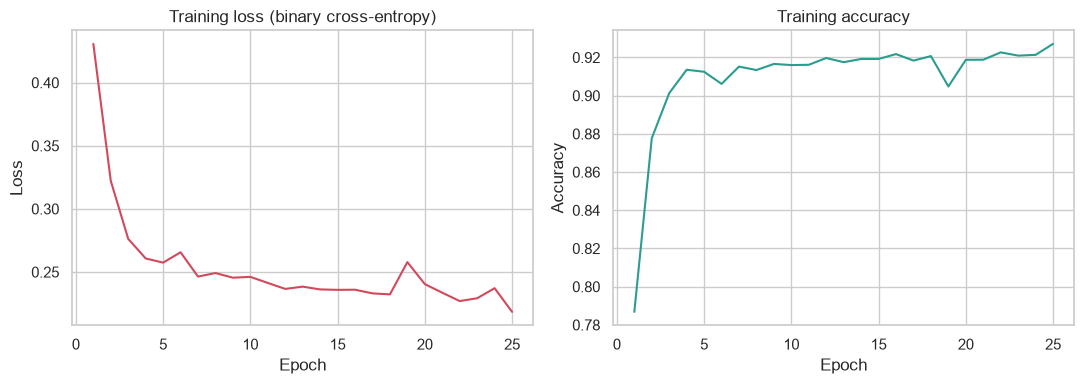

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), loss_history, color="#d1495b")
axes[0].set_title("Training loss (binary cross-entropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, EPOCHS + 1), accuracy_history, color="#2a9d8f")
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


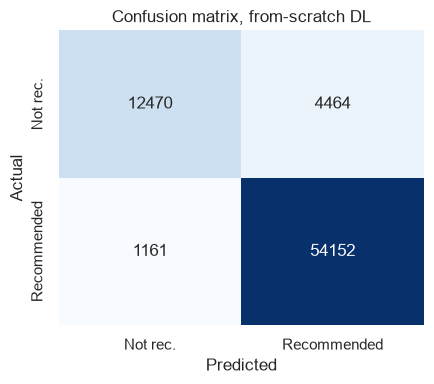

In [39]:
plt.figure(figsize=(4.5, 4))
cm_dl = confusion_matrix(y_test, dl_test_pred)
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not rec.", "Recommended"], yticklabels=["Not rec.", "Recommended"])
plt.title("Confusion matrix, from-scratch DL")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


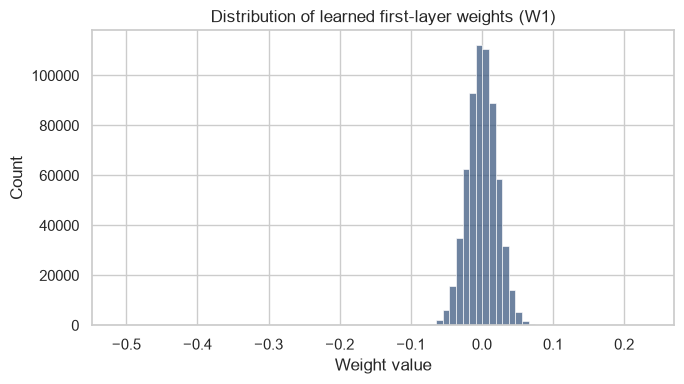

In [40]:
plt.figure(figsize=(7, 4))
sns.histplot(W1.flatten(), bins=80, color="#3d5a80")
plt.title("Distribution of learned first-layer weights (W1)")
plt.xlabel("Weight value")
plt.tight_layout()
plt.show()


After training, the first-layer weights settle into a roughly symmetric
distribution centered near zero, with no obvious pile-up right at zero and
no runaway extreme values. A pile-up at zero would point to dead ReLU units
that stopped learning, and extreme values would point to exploding
gradients, so this shape is a reasonable sign that the He-style
initialization and the chosen learning rate kept training numerically
stable.


The from-scratch network does not have a single coefficient per feature
the way Logistic Regression does; each input feature connects to all 128
first-layer units through its own row of `W1`, so no single number
captures "how much this word matters" on its own. Averaging the absolute
value of that row across all 128 units is a reasonable stand-in: a word
whose row of weights is large in magnitude, in either direction, on
average, is one the first layer is paying attention to.

In the code, `np.abs(W1)` takes the absolute value of every entry in the
weight matrix at once, throwing away the sign so a strongly negative
connection and a strongly positive one both count as "attention" rather
than cancelling out. `.mean(axis=1)` then averages across the columns
(`axis=1`, the 128 hidden units) for each row, collapsing the matrix down
to one number per input feature. Wrapping that in a `pd.Series` indexed by
the DL vocabulary and calling `.sort_values(ascending=False).head(15)`
lists the 15 terms with the strongest average signal, the same pattern
used for the Logistic Regression coefficients earlier.


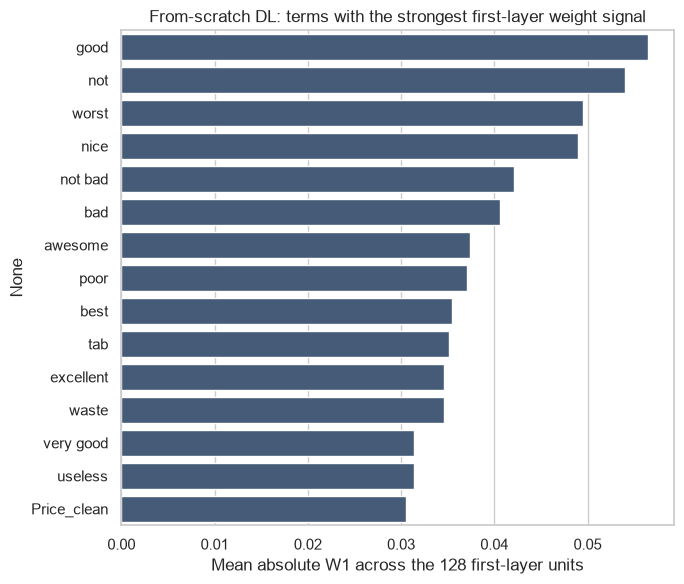

In [41]:
dl_text_feature_names = tfidf_dl.get_feature_names_out()
dl_all_feature_names = np.append(dl_text_feature_names, "Price_clean")
mean_abs_w1 = np.abs(W1).mean(axis=1)

dl_signal = pd.Series(mean_abs_w1, index=dl_all_feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(y=dl_signal.index, x=dl_signal.values, color="#3d5a80", orient="h")
plt.title("From-scratch DL: terms with the strongest first-layer weight signal")
plt.xlabel("Mean absolute W1 across the 128 first-layer units")
plt.tight_layout()
plt.show()


Some of the same strong sentiment words that stood out in the Logistic
Regression coefficients above also show up here, though not in quite the
same order. That is worth noting: the DL model is working from a smaller
5,000-term vocabulary and folding everything through a nonlinear three-layer
composition rather than a single linear weighting, so we would not expect an
identical ranking. What matters is that both models are converging on
genuinely similar lexical signal from the text, which is a reasonable
indication that the from-scratch network learned something sensible rather
than something arbitrary.


## Comparing all four models


In [42]:
combined_results = pd.concat([
    classical_results,
    pd.DataFrame(dl_metrics, index=["From-scratch DL"]),
])
display(combined_results.style.format("{:.4f}").highlight_max(color="#d8f3dc", axis=0))


,Accuracy,Precision,Recall,F1
Logistic Regression,0.9250,0.9279,0.9780,0.9523
Linear SVM,0.9295,0.9344,0.9765,0.9550
Multinomial NB,0.9035,0.8951,0.9900,0.9402
From-scratch DL,0.9221,0.9238,0.9790,0.9506


C:\Users\minorin\AppData\Local\Temp\ipykernel_16100\2780701865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_results.index, y=combined_results["Accuracy"], palette="crest")


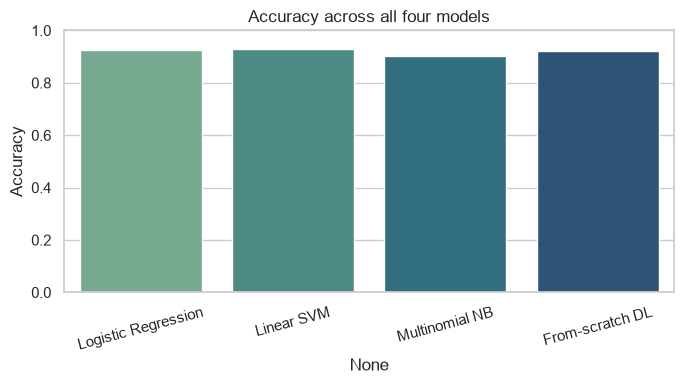

In [43]:
plt.figure(figsize=(7, 4))
sns.barplot(x=combined_results.index, y=combined_results["Accuracy"], palette="crest")
plt.title("Accuracy across all four models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


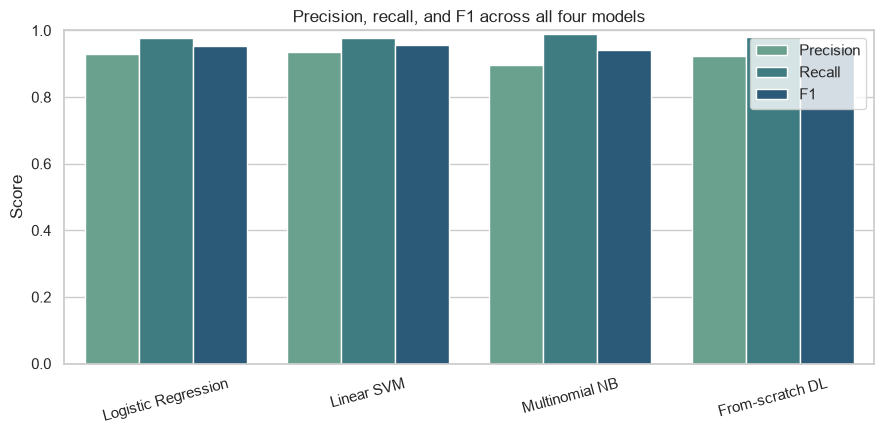

In [44]:
metrics_long = combined_results[["Precision", "Recall", "F1"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=metrics_long, x="index", y="Score", hue="Metric", palette="crest")
plt.title("Precision, recall, and F1 across all four models")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="")
plt.tight_layout()
plt.show()


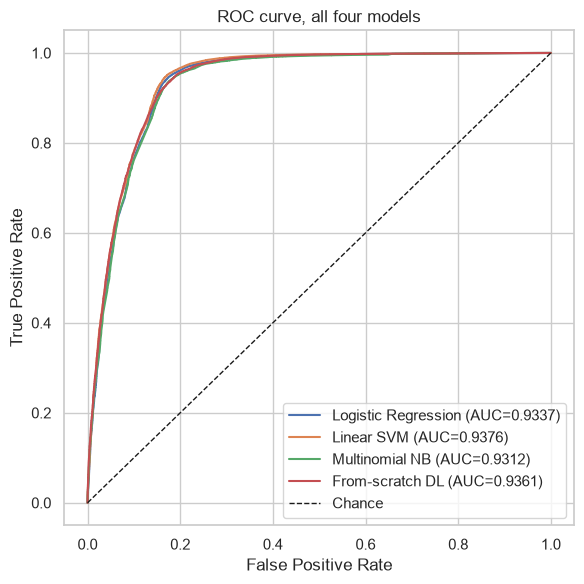

In [45]:
plt.figure(figsize=(6, 6))
for name, score in [
    ("Logistic Regression", score_lr),
    ("Linear SVM", score_svm),
    ("Multinomial NB", score_nb),
    ("From-scratch DL", dl_test_scores),
]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve, all four models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### So which model actually wins, and why

Linear SVM comes out slightly ahead by F1 at 0.9550, with Logistic
Regression close behind at 0.9523 and the from-scratch deep learning
model right there with them at 0.9506. Multinomial Naive Bayes trails the
other three at 0.9402, though "trails" is relative here; every model in
this comparison clears 94% F1.

Two separate things explain why these scores sit as high as they do, and
it is worth being precise about which is which. The first is the fix made
earlier in this notebook: switching from `Review` to `Summary` cut the
exact-text overlap between train and test from 99.1% down to 59.7%, so
these numbers are no longer mostly measuring memorization of boilerplate
strings the way an earlier version of this notebook's `Review`-based
results were (that version scored close to 0.99 F1 across the board,
noticeably higher than these numbers, for exactly that reason). The second
is the purity finding from the EDA section: even setting exact-text
overlap aside entirely, about three in four rows carry a Summary whose
label is at least 95% consistent across every row that shares that exact
text, because sentiment words in this dataset correlate that strongly with
rating regardless of whether the model has seen that specific string
before. That second effect is not a flaw in the evaluation; it is a real
property of how people write these summaries, and it means a genuinely
generalizing model should still score well here, just not as artificially
well as the Review-based version did.

Within that context, the same pattern that showed up under the old
representation still holds: the three models built on a linear decision
boundary over the TF-IDF features, Logistic Regression, Linear SVM, and
the from-scratch network's effectively-linear first layer before any
nonlinearity is applied, land within half a point of each other. That
closeness suggests the underlying task is still close to linearly
separable even on the richer Summary text, once a review carries a
handful of strongly positive or negative words. The deep learning model
does not clearly beat the linear models for the same reason it did not
before: a nonlinear network's extra capacity only pays off when the true
relationship between input and output is not already close to linear, and
a bag-of-words sentiment signal mostly is.

Naive Bayes tells a slightly different story from the linear models. Its
recall is the highest of all four at 0.9900, meaning it catches almost
every genuinely recommended review, but its precision is the lowest at
0.8951, meaning it also mislabels more not-recommended reviews as
recommended than the other three do. That trade-off fits its independence
assumption between words: without the ability to weigh combinations of
words against each other the way a linear model's learned coefficients
can, it leans harder on individual strongly positive words being present
at all, which pushes it toward predicting "recommended" more liberally.
It never sees the Price feature either, unlike Logistic Regression and
the SVM, a second, smaller handicap layered on top of the same modeling
limitation.

If anything is still holding the from-scratch network back from clearly
beating the linear models, it remains the 5,000-term vocabulary cap needed
to keep a dense NumPy forward and backward pass tractable, against the
classical models' access to Summary's full, now much larger, vocabulary.
That the DL model still lands within half a point of Logistic Regression
despite that handicap, on a genuinely harder and more honest version of
this task than the one this notebook started with, is a reasonable sign
that the from-scratch implementation is learning a sound representation
rather than a weak one.

In [46]:
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(exist_ok=True)

best_classical_name = classical_results["F1"].idxmax()
best_classical_model = {"Logistic Regression": log_reg, "Linear SVM": linear_svm, "Multinomial NB": naive_bayes}[best_classical_name]
print(f"Best classical model by F1: {best_classical_name}")

joblib.dump(
    {
        "model": best_classical_model,
        "model_name": best_classical_name,
        "tfidf_vectorizer": tfidf_classical,
        "price_scaler": price_scaler,
        "uses_price": best_classical_name != "Multinomial NB",
    },
    MODEL_DIR / "model_pipeline.joblib",
)

joblib.dump(list(all_feature_names), MODEL_DIR / "feature_names.joblib")

input_schema = {
    "inputs": {"Summary": "string", "Price": "string (raw, e.g. '?10,499')"},
    "target": "is_recommended (0/1), derived from Rate >= 4",
    "classical_model": best_classical_name,
    "notes": "TF-IDF over the Summary field (full vocabulary, 1-2 grams), "
             "concatenated with standardized Price, except Multinomial NB, "
             "which uses TF-IDF text only. Summary is used instead of Review "
             "because Review is overwhelmingly repeated boilerplate text "
             "(see the notebook's EDA section).",
}
with open(MODEL_DIR / "input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)

print("Saved model_pipeline.joblib, feature_names.joblib, input_schema.json")


Best classical model by F1: Linear SVM


Saved model_pipeline.joblib, feature_names.joblib, input_schema.json


In [47]:
np.savez(
    MODEL_DIR / "dl_weights.npz",
    W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3,
)
print("Saved dl_weights.npz")


Saved dl_weights.npz


In [48]:
reloaded = joblib.load(MODEL_DIR / "model_pipeline.joblib")
reloaded_pred = reloaded["model"].predict(
    X_test_classical if reloaded["uses_price"] else X_test_text_classical
)
assert np.array_equal(reloaded_pred, {"Logistic Regression": pred_lr, "Linear SVM": pred_svm, "Multinomial NB": pred_nb}[best_classical_name]), \
    "Reloaded classical model predictions do not match in-memory predictions!"

dl_weights = np.load(MODEL_DIR / "dl_weights.npz")
reloaded_scores = predict_dl(
    X_test_dl, dl_weights["W1"], dl_weights["b1"], dl_weights["W2"],
    dl_weights["b2"], dl_weights["W3"], dl_weights["b3"],
).ravel()
assert np.allclose(reloaded_scores, dl_test_scores, atol=1e-5), \
    "Reloaded DL weights do not reproduce in-memory predictions!"

print("Reload-and-verify passed: both artifacts reproduce their in-memory predictions.")


Reload-and-verify passed: both artifacts reproduce their in-memory predictions.
